# Spatial Analysis of Traffic Crash Severity in Detroit, Michigan

## Exploring the Relationship Between Crash Severity and Population Distribution


## Problem Statement

Traffic crashes remain a significant public safety issue in major U.S. cities.
Detroit, Michigan has experienced persistent traffic safety challenges,
including fatal and injury crashes.

This project explores the spatial and temporal distribution of traffic crashes
in Detroit using a 2011 crash dataset. Specifically, this analysis examines:

- How crash frequency varies across months
- How crash severity is distributed across the city
- Whether crashes spatially align with population distribution at the census tract level

Understanding these patterns can support urban planning decisions, roadway safety interventions,
and Vision Zero–type policies aimed at reducing severe and fatal crashes.

## Data Sources

The analysis uses the following datasets:

### 1. Detroit Traffic Crash Data
- Source: City of Detroit Open Data Portal (ArcGIS FeatureServer)
- Contains: Crash date, location, injury severity, and roadway characteristics
- Time period: 2011 sample dataset (limited to 2000 records via API)

### 2. Census Tract Boundaries
- Source: U.S. Census Bureau TIGER/Line Shapefiles (2011)
- Geographic unit: Census tracts within Wayne County, clipped to Detroit city boundary

### 3. Population Data
- Source: American Community Survey (ACS) 5-Year Estimates (2011)
- Variable used: Total Population (B01001_001E)
- Geographic unit: Census tract level

These datasets were integrated using Python libraries including pandas, geopandas,
and matplotlib for spatial and statistical exploration.

## Analytical Approach

To explore crash patterns in Detroit, the following steps were taken:

1. Data Cleaning and Preparation
   - Converted and verified date formats
   - Re-coded injury severity categories
   - Ensured consistent coordinate reference systems (CRS)

2. Temporal Analysis
   - Generated a monthly crash frequency chart
   - Examined seasonal variation in crash occurrence
   - Created boxplots to assess variation in crash severity by month

3. Spatial Analysis
   - Clipped census tracts to Detroit city boundary
   - Merged tract-level population data
   - Mapped crash severity across Detroit
   - Overlayed crash locations with census tract population

4. Cartographic Enhancements
   - Converted data to projected CRS (EPSG:3857)
   - Added scale bar and north arrow
   - Designed readable legends and titles

This workflow allows for both temporal and spatial insights into crash patterns.

## Key Insights

Several important patterns emerge from the exploratory analysis:

- **Seasonal Variation:** Crash frequencies vary across months, with noticeable peaks toward the end of the year. This suggests possible seasonal effects such as weather conditions or holiday travel patterns influencing crash occurrence.

- **Severity Distribution:** Property-damage-only crashes dominate the dataset, while fatal and severe injury crashes occur much less frequently. This pattern is consistent across months.

- **Monthly Variability:** The boxplot shows that property-damage-only crashes have the greatest monthly variability, while fatal crashes remain relatively stable and low throughout the year.

- **Spatial Concentration:** Crash points are widely distributed across Detroit but appear denser in more populated census tracts and along major roadway corridors.

- **Population Relationship:** Higher-population tracts tend to show greater crash concentration, suggesting that traffic volume and density may contribute to overall crash frequency.

In conclusion crash patterns in Detroit appear influenced by both temporal factors (seasonality) and spatial factors (population density and roadway structure).

## Limitations

This analysis is exploratory and has several limitations:

- The crash dataset includes only 2000 records (API limit).
- Data represents one year (2011), limiting temporal generalization.
- Crash rates per capita were not calculated in this stage.

Future work could include:
- Kernel density estimation
- Hotspot analysis (Getis-Ord Gi*)
- Multi-year trend comparison

## Conclusion

This exploratory spatial analysis demonstrates how integrating crash data
with demographic information can reveal important safety patterns
within Detroit.

Using pandas, geopandas, and matplotlib, this notebook provides
both temporal and spatial insights that can inform planning,
transportation policy, and safety interventions. The code for the Assignment is as follows

In [44]:
#Importing Python Libraries
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import folium
from folium import plugins



Data loading and prepocessing

In [45]:
# loading crash data
detroit_url = "https://services2.arcgis.com/qvkbeam7Wirps6zC/arcgis/rest/services/Traffic_Crashes/FeatureServer/0/query?where=1%3D1&outFields=*&f=geojson"

crash = gpd.read_file(detroit_url)


crash.head()

,OBJECTID,crash_id,primary_road,intersecting_road,crash_date,day,month,year,hour,weekday,...,is_train_involved,is_school_bus_involved,is_motorcycle_involved,is_bicycle_involved,is_deer_involved,longitude,latitude,geom,geog,geometry
0,1,8229770,WYOMING ST,JAMES COUZENS FWY,2011-12-31,31,12,2011,19,7,...,false,false,false,false,false,-83.15984,42.40577,"{\n ""coordinates"": [\n -8.315983417299999e...","{\n ""coordinates"": [\n -83.159834173,\n ...",POINT (-83.15983 42.40577)
1,2,8229739,CHICAGO BLDV,LIVERNOIS,2011-12-31,31,12,2011,5,7,...,false,false,false,false,false,-83.13870,42.36658,"{\n ""coordinates"": [\n -8.313870509200000e...","{\n ""coordinates"": [\n -83.138705092,\n ...",POINT (-83.13871 42.36658)
2,3,8234576,N/B M-10,WYOMING,2011-12-31,31,12,2011,15,7,...,false,false,false,false,false,-83.15758,42.40482,"{\n ""coordinates"": [\n -8.315758017300000e...","{\n ""coordinates"": [\n -83.157580173,\n ...",POINT (-83.15758 42.40482)
3,4,8229704,GREENFIELD,W MCNICHOLS,2011-12-31,31,12,2011,16,7,...,false,false,false,false,false,-83.19931,42.41600,"{\n ""coordinates"": [\n -8.319930824999990e...","{\n ""coordinates"": [\n -83.19930825,\n ...",POINT (-83.19931 42.416)
4,5,8229724,GRAND RIVER AVE,SALEM ST,2011-12-31,31,12,2011,18,7,...,false,false,false,false,false,-83.28568,42.42756,"{\n ""coordinates"": [\n -8.328567981099999e...","{\n ""coordinates"": [\n -83.285679811,\n ...",POINT (-83.28568 42.42756)


In [46]:
# dataset information
crash.columns


Index(['OBJECTID', 'crash_id', 'primary_road', 'intersecting_road',
       'crash_date', 'day', 'month', 'year', 'hour', 'weekday',
       'crash_type_code', 'highway_classification_code', 'community_code',
       'jurisdiction_code', 'lane_departure_type_code', 'surface_type',
       'road_condition_code', 'weather_condition_code',
       'lighting_condition_code', 'speed_limit', 'num_lanes', 'num_units',
       'num_occupants', 'most_severe_injury_code', 'num_fatal_injuries',
       'num_suspected_serious_injuries', 'num_suspected_minor_injuries',
       'num_possible_injuries', 'is_property_damage_only',
       'is_secondary_crash', 'is_traffic_control_disregarded',
       'is_red_light_run_involved', 'is_hit_and_run_involved',
       'is_alcohol_involved', 'is_drug_involved',
       'is_unbelted_person_involved', 'is_work_zone_involved',
       'is_speeding_driver_involved', 'is_distracted_driver_involved',
       'is_driveway_involved', 'is_pedestrian_involved',
       'is_elderly

In [47]:
crash.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   OBJECTID                        2000 non-null   int32         
 1   crash_id                        2000 non-null   int32         
 2   primary_road                    2000 non-null   object        
 3   intersecting_road               2000 non-null   object        
 4   crash_date                      2000 non-null   datetime64[ms]
 5   day                             2000 non-null   int32         
 6   month                           2000 non-null   int32         
 7   year                            2000 non-null   int32         
 8   hour                            2000 non-null   int32         
 9   weekday                         2000 non-null   int32         
 10  crash_type_code                 2000 non-null   int32         
 

In [48]:

crash['most_severe_injury_code'].unique()

array([3, 4, 5, 2, 1], dtype=int32)

In [49]:


crash['CRASH_SEVERITY'] = crash['most_severe_injury_code'].replace({
    1: '1. Fatal Injury',
    2: '2. Severe Injury',
    3: '3. Minor Injury',
    4: '4. Possible Injury',
    5: '5. Property Damage Only'
})

crash['CRASH_SEVERITY'].unique()

array(['3. Minor Injury', '4. Possible Injury', '5. Property Damage Only',
       '2. Severe Injury', '1. Fatal Injury'], dtype=object)

In [50]:
crash['crash_date']

,crash_date
0,2011-12-31
1,2011-12-31
2,2011-12-31
3,2011-12-31
4,2011-12-31
...,...
1995,2011-11-22
1996,2011-11-22
1997,2011-11-22
1998,2011-11-22


In [51]:
crash['Month'] = crash['crash_date'].dt.to_period('M')
crash['Month'] = crash['Month'].dt.to_timestamp()

crash[['crash_date', 'Month']].head()

,crash_date,Month
0,2011-12-31,2011-12-01
1,2011-12-31,2011-12-01
2,2011-12-31,2011-12-01
3,2011-12-31,2011-12-01
4,2011-12-31,2011-12-01


HISTOGRAMS

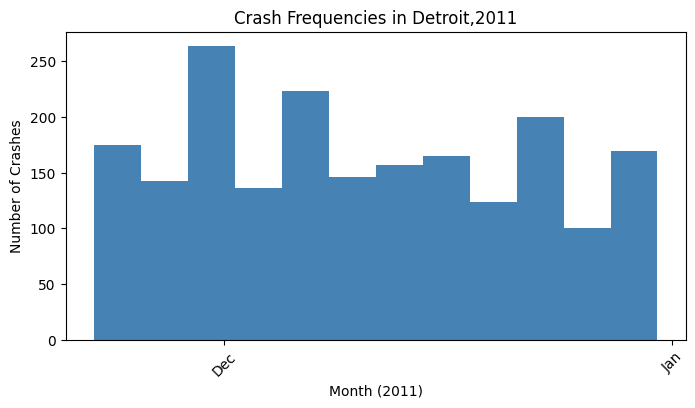

In [52]:
# Creating Histogram for Crash frequencies in Detroit in 2011
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(crash['crash_date'], bins=12, color='steelblue')


ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))


ax.tick_params(axis='x', rotation=45)


ax.set_xlabel('Month (2011)')
ax.set_ylabel('Number of Crashes')
ax.set_title('Crash Frequencies in Detroit,2011')

plt.show()

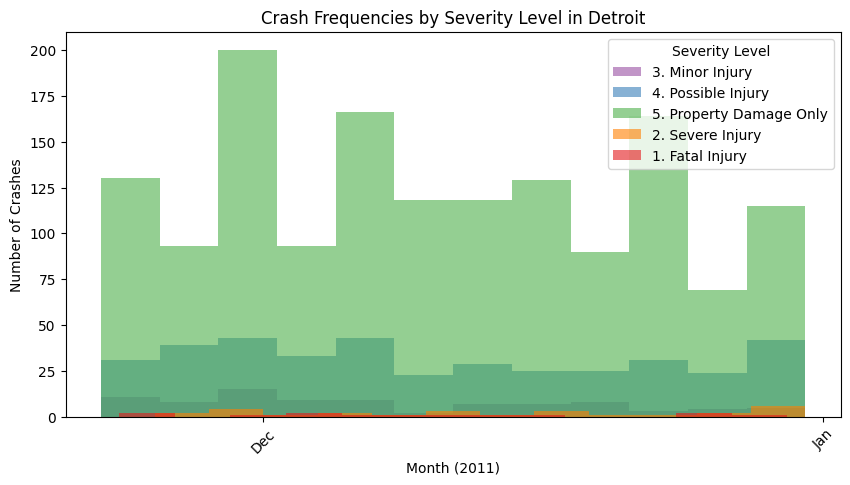

In [53]:
#Creating Histogram for Crash Frequencies by Severity Level in Detroit
fig, ax = plt.subplots(figsize=(10, 5))


colors = {
    '1. Fatal Injury': '#e41a1c',
    '2. Severe Injury': '#ff7f00',
    '3. Minor Injury': '#984ea3',
    '4. Possible Injury': '#377eb8',
    '5. Property Damage Only': '#4daf4a'
}


for level in crash['CRASH_SEVERITY'].unique():
    subset = crash[crash['CRASH_SEVERITY'] == level]

    ax.hist(
        subset['crash_date'],
        bins=12,
        alpha=0.6,
        label=level,
        color=colors[level]
    )


ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=45)


ax.set_xlabel('Month (2011)')
ax.set_ylabel('Number of Crashes')
ax.set_title('Crash Frequencies by Severity Level in Detroit')


ax.legend(title="Severity Level")

plt.show()

BOXPLOT

In [54]:
# Creating BoxPlot for the Distribution of Monthly Crash Frequencies by Severity
crash['Month'] = crash['crash_date'].dt.to_period('M')


monthly_counts = crash.groupby(['Month', 'CRASH_SEVERITY']).size().reset_index(name='Total_Crashes')


monthly_counts['Month'] = monthly_counts['Month'].dt.to_timestamp()

monthly_counts.head()

,Month,CRASH_SEVERITY,Total_Crashes
0,2011-11-01,1. Fatal Injury,2
1,2011-11-01,2. Severe Injury,6
2,2011-11-01,3. Minor Injury,29
3,2011-11-01,4. Possible Injury,101
4,2011-11-01,5. Property Damage Only,382


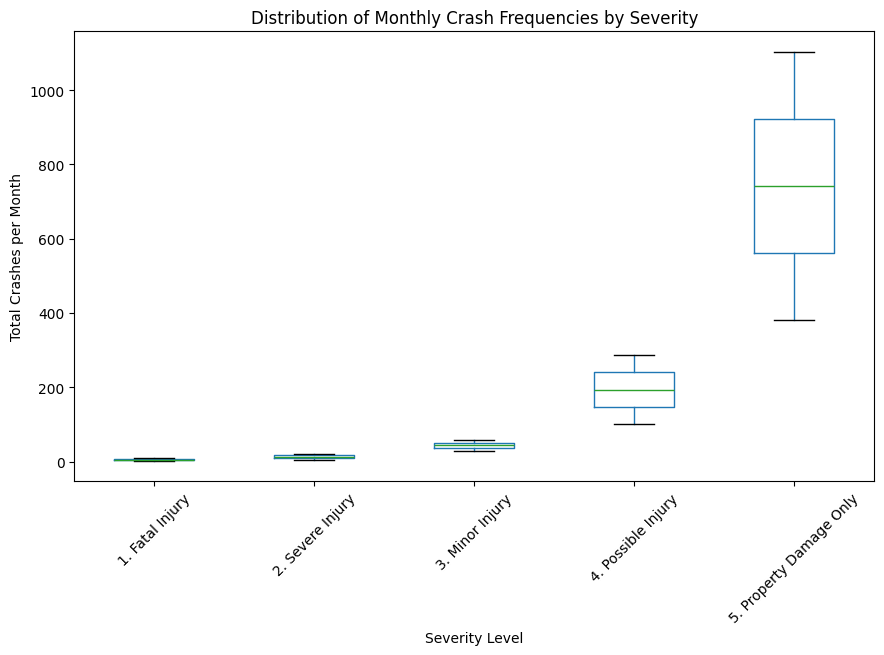

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

monthly_counts.boxplot(
    column='Total_Crashes',
    by='CRASH_SEVERITY',
    ax=ax
)

plt.grid(False)

ax.set_xlabel("Severity Level")
ax.set_ylabel("Total Crashes per Month")
ax.set_title("Distribution of Monthly Crash Frequencies by Severity")


plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

MAPS

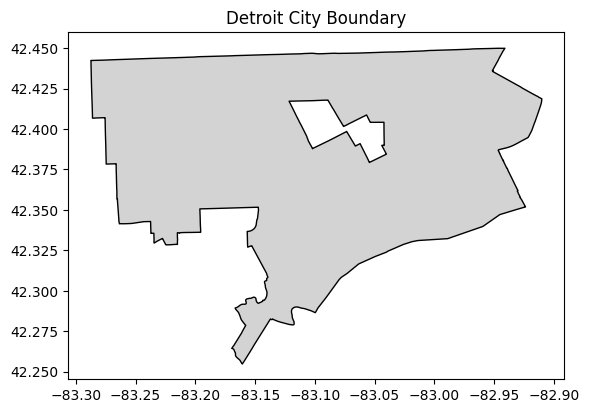

In [56]:
# Loading Census Places (cities)
places = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2022/PLACE/tl_2022_26_place.zip"
)

# Detroit place FIPS = 22000
detroit = places[places['NAME'] == 'Detroit']

# Ploting Detroit boundary
detroit.plot(edgecolor='black', facecolor='lightgray')
plt.title("Detroit City Boundary")
plt.show()

DEMOGRAPHIC DATA

In [57]:
!pip install census

from census import Census
import pandas as pd

c = Census("c82c1bdebe266e03a6ce728af8be8ab63e23efd0")

In [58]:
# Detroit population
detroit_census = c.acs5.state_place(
    fields=('NAME', 'B01001_001E'),
    state_fips="26",
    place="22000",
    year=2011
)

# Converting to DataFrame
detroit_census = pd.DataFrame(detroit_census)

# Renaming column
detroit_census = detroit_census.rename(
    columns={"B01001_001E": "Total_Population"}
)

detroit_census

,NAME,Total_Population,state,place
0,"Detroit city, Michigan",738223.0,26,22000


In [59]:
# Loading Michigan census tracts
tracts = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_26_tract.zip"
)

tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,26,081,014701,26081014701,147.01,Census Tract 147.01,G5020,S,3476917,26945,+42.8412855,-085.6702447,"POLYGON ((-85.67902 42.85516, -85.67895 42.855..."
1,26,081,014703,26081014703,147.03,Census Tract 147.03,G5020,S,2465869,0,+42.8477989,-085.6541309,"POLYGON ((-85.66374 42.85493, -85.66321 42.854..."
2,26,081,014803,26081014803,148.03,Census Tract 148.03,G5020,S,57151537,111620,+42.7900949,-085.6047898,"POLYGON ((-85.66381 42.79992, -85.66373 42.805..."
3,26,081,014805,26081014805,148.05,Census Tract 148.05,G5020,S,12921349,28122,+42.8278175,-085.6264339,"POLYGON ((-85.66359 42.82182, -85.66359 42.822..."
4,26,081,000200,26081000200,2,Census Tract 2,G5020,S,1631723,79009,+43.0172894,-085.6551305,"POLYGON ((-85.67247 43.01375, -85.67236 43.014..."


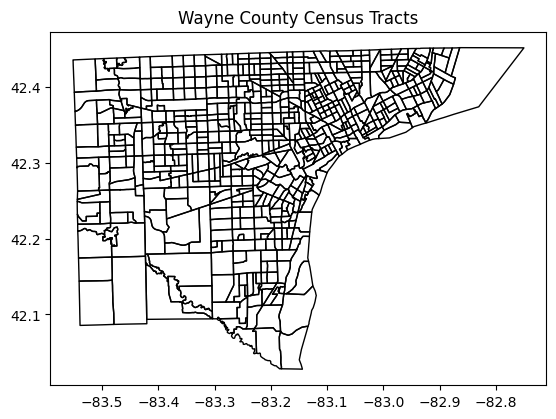

In [60]:
# Filtering Wayne County tracts
wayne_tracts = tracts[tracts['COUNTYFP'] == '163']

wayne_tracts.plot(edgecolor='black', facecolor='none')
plt.title("Wayne County Census Tracts")
plt.show()

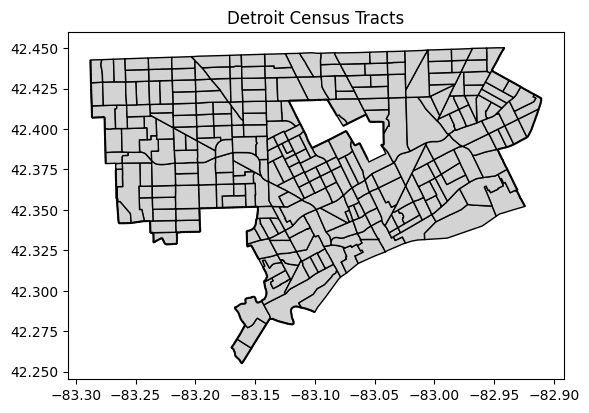

In [61]:
# Ensuring that they are in the same CRS
wayne_tracts = wayne_tracts.to_crs(detroit.crs)

# Clipping tracts to Detroit boundary
detroit_tracts = gpd.clip(wayne_tracts, detroit)

detroit_tracts.plot(edgecolor='black', facecolor='lightgray')
plt.title("Detroit Census Tracts")
plt.show()

In [62]:
# Getting  tract-level population for Wayne County
tract_pop = c.acs5.state_county_tract(
    fields=('NAME', 'B01001_001E'),
    state_fips="26",
    county_fips="163",
    tract="*",
    year=2011
)

tract_pop = pd.DataFrame(tract_pop)

tract_pop = tract_pop.rename(columns={
    "B01001_001E": "Total_Population"
})

tract_pop.head()

,NAME,Total_Population,state,county,tract
0,"Census Tract 5238, Wayne County, Michigan",4988.0,26,163,523800
1,"Census Tract 5240, Wayne County, Michigan",3589.0,26,163,524000
2,"Census Tract 5241, Wayne County, Michigan",4112.0,26,163,524100
3,"Census Tract 5254, Wayne County, Michigan",1731.0,26,163,525400
4,"Census Tract 5257, Wayne County, Michigan",4879.0,26,163,525700


In [63]:
# Converting to string
detroit_tracts['TRACTCE'] = detroit_tracts['TRACTCE'].astype(str)
tract_pop['tract'] = tract_pop['tract'].astype(str)

# Merging tract population to detroit tract
detroit_tracts_pop = detroit_tracts.merge(
    tract_pop,
    left_on='TRACTCE',
    right_on='tract'
)

detroit_tracts_pop.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,NAME_y,Total_Population,state,county,tract
0,26,163,579600,26163579600,5796,Census Tract 5796,G5020,S,1369237,0,+42.2566755,-083.1515705,"MULTILINESTRING ((-83.16073 42.25533, -83.1589...","Census Tract 5796, Wayne County, Michigan",3693.0,26,163,579600
1,26,163,579300,26163579300,5793,Census Tract 5793,G5020,S,1437155,0,+42.2696193,-083.1436539,"MULTILINESTRING ((-83.15303 42.2644, -83.15142...","Census Tract 5793, Wayne County, Michigan",2911.0,26,163,579300
2,26,163,579700,26163579700,5797,Census Tract 5797,G5020,S,1573663,10412,+42.2425758,-083.1545620,"LINESTRING (-83.16105 42.25496, -83.16086 42.2...","Census Tract 5797, Wayne County, Michigan",3256.0,26,163,579700
3,26,163,577000,26163577000,5770,Census Tract 5770,G5020,S,1536700,1439,+42.2522226,-083.1670939,"MULTILINESTRING ((-83.16726 42.26228, -83.167 ...","Census Tract 5770, Wayne County, Michigan",4551.0,26,163,577000
4,26,163,577100,26163577100,5771,Census Tract 5771,G5020,S,1131134,0,+42.2575758,-083.1759449,"MULTILINESTRING ((-83.16991 42.26458, -83.1693...","Census Tract 5771, Wayne County, Michigan",3050.0,26,163,577100


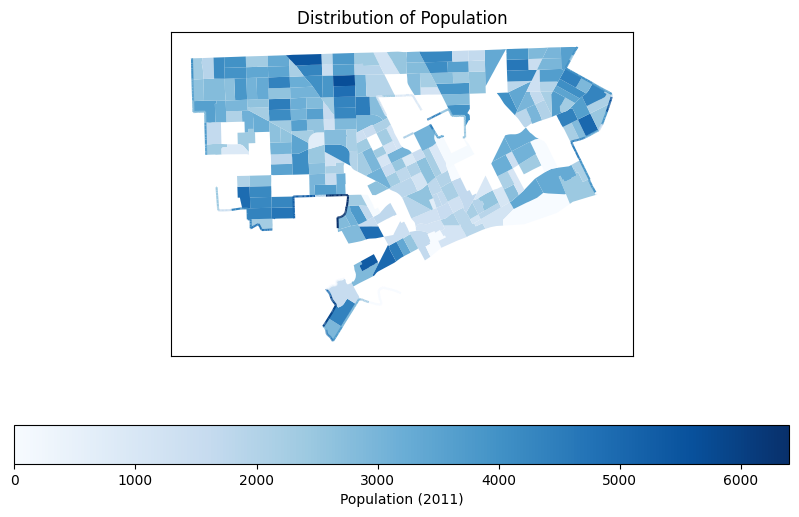

In [64]:
fig, ax = plt.subplots(figsize=(10,6))

detroit_tracts_pop.plot(
    column="Total_Population",
    cmap="Blues",
    legend=True,
    ax=ax,
    legend_kwds={'label': "Population (2011)", 'orientation': "horizontal"}
)

ax.set_title("Distribution of Population")
ax.set_xticks([])
ax.set_yticks([])

plt.show()

In [65]:
print(detroit_tracts_pop.crs)
print(crash.crs)

EPSG:4269
EPSG:4326


In [66]:
detroit_tracts_pop = detroit_tracts_pop.to_crs(crash.crs)

In [67]:
print(detroit_tracts_pop.crs)
print(crash.crs)

EPSG:4326
EPSG:4326


Final Maps

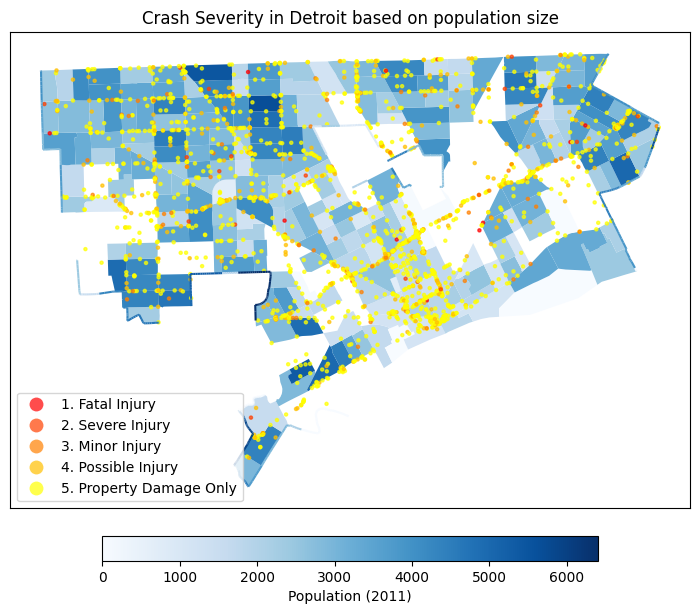

In [70]:
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')

# Plotting census tract population (polygon layer first)
plot1 = detroit_tracts_pop.plot(
    ax=ax,
    column="Total_Population",
    cmap='Blues',
    legend=True,
    legend_kwds={
        'label': "Population (2011)",
        'orientation': "horizontal",
        'shrink': 0.5
    }
)

# Plotting crash points on top
crash.plot(
    ax=plot1,
    column='CRASH_SEVERITY',
    cmap='autumn',
    legend=True,
    markersize=5,
    alpha=0.7
)


ax.set_xticks([])
ax.set_yticks([])

# Title
ax.set_title("Crash Severity in Detroit based on population size")

plt.show()

In [71]:
# Installing the matplotlib_scalebar library
!pip install matplotlib_scalebar
# importing the ScaleBar module
from matplotlib_scalebar.scalebar import ScaleBar

In [72]:
 #Installing the geo_northarrow library
# This is also an example of installing libraries directly from GitHub
!pip install git+https://github.com/pmdscully/geo_northarrow.git
# importing the add_north_arrow function
from geo_northarrow import add_north_arrow


  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-2l9t_ff5
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-2l9t_ff5
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14940 sha256=8adf1923d7df65523ec273b8503774e31bb11b674cbdf22e163e362cc2c4735a
  Stored in directory: /tmp/pip-ephem-wheel-cache-thnoa8b4/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


In [73]:
# Convert Detroit census tract population layer
detroit_tracts_pop = detroit_tracts_pop.to_crs(3857)

# Convert crash layer
crash = crash.to_crs(3857)

# Confirm CRS
print(detroit_tracts_pop.crs)
print(crash.crs)

EPSG:3857
EPSG:3857


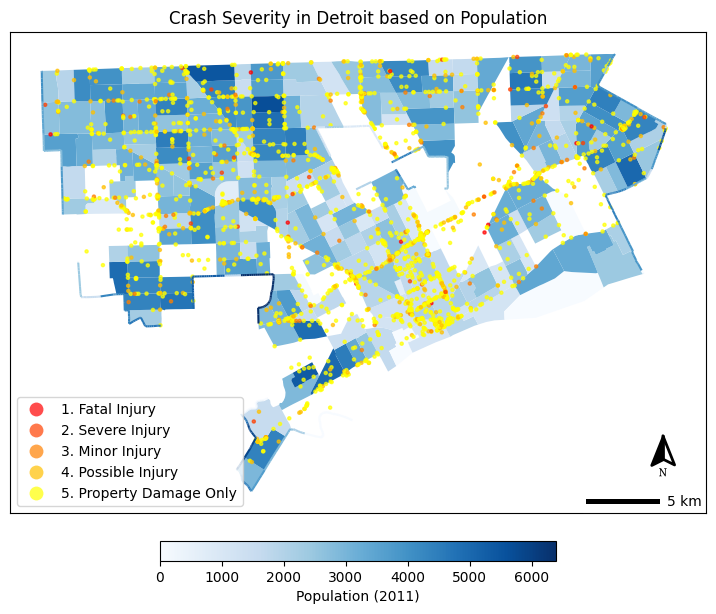

In [75]:
fig, ax = plt.subplots(figsize=(10, 6), layout='constrained')

# Plotting Detroit census tract population
plot1 = detroit_tracts_pop.plot(
    ax=ax,
    column="Total_Population",
    cmap='Blues',
    legend=True,
    legend_kwds={
        'label': "Population (2011)",
        'orientation': "horizontal",
        'shrink': 0.4
    }
)

# Plot crash points on top
crash.plot(
    ax=plot1,
    column='CRASH_SEVERITY',
    cmap="autumn",
    legend=True,
    markersize=5,
    alpha=0.7
)

# Removing axis tick labels
ax.set_xticks([])
ax.set_yticks([])

# Title
ax.set_title("Crash Severity in Detroit based on Population")

# Addig scale bar
scale1 = ScaleBar(
    dx=1,
    location="lower right",
    scale_loc="right",
    box_alpha=0.1
)
ax.add_artist(scale1)

# Adding north arrow
add_north_arrow(
    ax,
    scale=.45,
    xlim_pos=.95,
    ylim_pos=.1,
    color='#000',
    text_scaler=2,
    text_yT=-1.25
)

plt.show()